<a href="https://colab.research.google.com/github/achandlabe24/UCS420_Cogntive_Computing/blob/main/UCS420_LA9_Starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UCS420 Lab Assignment 9 — NLP Text Preprocessing
Enter your roll number and name, then run all cells.

In [20]:
ROLL_NO = 1024170259 # <-- your full roll number
NAME = "Arnav Chandla" # <-- your name

import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)
assert ROLL_NO > 0 and NAME, "Enter your roll number and name first"

### Dataset generator — do not modify

In [21]:
import random, hashlib
import pandas as pd

def generate_dataset(roll_no):
    """Return (DataFrame of tickets, focus ticket IDs, fingerprint) for a roll number. Do not modify."""
    rng = random.Random(int(roll_no))

    subjects = [("LMS", ["LMS", "lms"]), ("Wi-Fi", ["Wi-Fi", "WiFi", "wifi"]), ("VPN", ["VPN"]),
                ("email", ["email", "e-mail"]), ("password", ["password"]), ("portal", ["student portal"]),
                ("projector", ["projector"]), ("laptop", ["laptop"]), ("MATLAB", ["MATLAB", "Matlab"]),
                ("Python", ["Python"]), ("printer", ["printer"]), ("server", ["server"])]
    actions = ["is not working", "keeps disconnecting", "failed to open", "is running slowly",
               "crashes while opening", "stopped responding", "is showing an error", "was working yesterday",
               "has stopped syncing", "keeps asking for login"]
    user_actions = ["cannot access", "can't open", "couldn't connect to", "am unable to use",
                    "tried restarting", "was locked out of", "keep getting logged out of", "reinstalled"]
    contexts = ["after resetting my password", "during the lab", "on my laptop", "since yesterday",
                "after the latest update", "when I use mobile hotspot", "before the assignment deadline",
                "while uploading the file", "after restarting the system", "when connected to campus Wi-Fi"]
    endings = ["Please help.", "Can you check this?", "I have tried several times!", "It worked yesterday.",
               "I don't know what changed.", "The same problem occurs again.", "Is there another solution?",
               "It works on another computer.", "This is urgent.", "Please resolve it."]
    challenges = {
        "negation": ["The Wi-Fi works, but the VPN doesn't.", "Why isn't the portal opening?",
                     "I can't login and I didn't change anything.", "It's not the laptop; it's the server.",
                     "Nothing works and nobody has replied.", "The printer won't print; it isn't jammed."],
        "numbers": ["Python 3.12 was installed yesterday.", "The file is 95.5% uploaded.",
                    "Error code 0x80070005 appears.", "I need Windows 11 by 5.30 p.m. today.",
                    "Only 2 of 30 PCs boot after 3.5 hours.", "Version 2.0.1 crashes at 99%."],
        "identifiers": ["Email me at helpdesk@university.edu.", "See https://lms.thapar.edu/help for details.",
                        "My roll no. is 1024-17-0259.", "Ticket #4521 is still open.",
                        "Call me on +91 98765 43210 or 0175-239-3201.",
                        "Write to it.helpdesk@thapar.edu or visit www.thapar.edu/it."],
        "punctuation": ["I tried again... still no response!!!", "The LMS says 'Not Submitted'.",
                        "Dr. Rao's lab PC (No. 14) is down.", "Is it fixed?? Pls reply ASAP :(",
                        "The state-of-the-art lab (Lab-3) is closed.", "Re-installing didn't help; log-in still fails!"],
    }

    tickets = []
    for _ in range(8 + int(roll_no) % 5):
        _, variants = rng.choice(subjects)
        s = rng.choice(variants)
        template = rng.randrange(3)
        if template == 0:
            text = f"{s} {rng.choice(actions)} {rng.choice(contexts)}. {rng.choice(endings)}"
        elif template == 1:
            text = f"I {rng.choice(user_actions)} the {s} {rng.choice(contexts)}. {rng.choice(endings)}"
        else:
            text = f"The {s} {rng.choice(actions)}. {rng.choice(endings)}"
        tickets.append(text[0].upper() + text[1:])
    for category in ["negation", "numbers", "identifiers", "punctuation"]:
        tickets.append(rng.choice(challenges[category]))
    rng.shuffle(tickets)

    df = pd.DataFrame({"Ticket_ID": [f"T{i + 1:02d}" for i in range(len(tickets))], "Ticket_Text": tickets})
    focus = [f"T{i:02d}" for i in sorted(rng.sample(range(1, len(tickets) + 1), 2))]
    fingerprint = hashlib.md5(("|".join(tickets) + str(int(roll_no))).encode()).hexdigest()[:8].upper()
    return df, focus, fingerprint

### Preprocessing pipeline — do not modify

In [22]:
import string
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

STOP = set(stopwords.words("english"))

def is_punct(token):
    """A token is punctuation if EVERY character in it is in string.punctuation (e.g. '.', '...', '``', "''")."""
    return all(ch in string.punctuation for ch in token)

def process_ticket(text):
    """The official pipeline. Returns sentences, lowercase tokens, punctuation, stopwords and final tokens."""
    sentences = sent_tokenize(text)
    tokens = [t.lower() for s in sentences for t in word_tokenize(s)]
    punct = [t for t in tokens if is_punct(t)]
    stops = [t for t in tokens if t in STOP]
    final = [t for t in tokens if not is_punct(t) and t not in STOP]
    return {"sentences": sentences, "tokens": tokens, "punct": punct, "stops": stops, "final": final}

In [23]:
df, FOCUS, FINGERPRINT = generate_dataset(ROLL_NO)
print(f"Roll number: {ROLL_NO}   Name: {NAME}   Fingerprint: {FINGERPRINT}   Tickets: {len(df)}\n")
print(df.to_string(index=False))
df.to_csv(f"{ROLL_NO}_generated_dataset.csv", index=False)

Roll number: 1024170259   Name: Arnav Chandla   Fingerprint: 76247C79   Tickets: 16

Ticket_ID                                                                               Ticket_Text
      T01                                     The student portal is running slowly. This is urgent.
      T02 Projector keeps asking for login while uploading the file. The same problem occurs again.
      T03                      Password is showing an error when I use mobile hotspot. Please help.
      T04                                     The VPN is not working. It works on another computer.
      T05                                  Printer stopped responding since yesterday. Please help.
      T06                                                              My roll no. is 1024-17-0259.
      T07              I tried restarting the Python when I use mobile hotspot. Can you check this?
      T08                                                     Nothing works and nobody has replied.
      T09      

---
## Q1. Preprocessing pipeline
Run process_ticket() on every ticket and show one table with, per ticket: sentences, tokens, punctuation tokens, stopwords, unique tokens and final tokens, plus a TOTAL row.

In [24]:
import pandas as pd

# Initialize lists to store metrics for each ticket
rows_data = []
all_unique_tokens = set()
all_final_tokens = []

for _, row in df.iterrows():
    ticket_id = row['Ticket_ID']
    text = row['Ticket_Text']

    # Process the ticket
    processed = process_ticket(text)

    # Extract lists
    sentences = processed['sentences']
    tokens = processed['tokens']
    punct = processed['punct']
    stops = processed['stops']
    final = processed['final']

    # Gather distinct tokens for overall unique count
    all_unique_tokens.update(tokens)

    # Store metrics
    rows_data.append({
        'Ticket_ID': ticket_id,
        'Sentences': len(sentences),
        'Tokens': len(tokens),
        'Punctuation': len(punct),
        'Stopwords': len(stops),
        'Unique Tokens': len(set(tokens)),
        'Final Tokens': len(final)
    })

# Create the main DataFrame
summary_df = pd.DataFrame(rows_data)

# Calculate totals
total_row = pd.DataFrame([{
    'Ticket_ID': 'TOTAL',
    'Sentences': summary_df['Sentences'].sum(),
    'Tokens': summary_df['Tokens'].sum(),
    'Punctuation': summary_df['Punctuation'].sum(),
    'Stopwords': summary_df['Stopwords'].sum(),
    'Unique Tokens': len(all_unique_tokens),
    'Final Tokens': summary_df['Final Tokens'].sum()
}])

# Append total row
final_summary_df = pd.concat([summary_df, total_row], ignore_index=True)

# Display the table
display(final_summary_df)

,Ticket_ID,Sentences,Tokens,Punctuation,Stopwords,Unique Tokens,Final Tokens
0,T01,2,11,2,4,9,5
1,T02,2,16,2,6,14,8
2,T03,2,14,2,4,13,8
3,T04,2,12,2,5,11,5
4,T05,2,9,2,0,8,7
5,T06,2,7,2,3,6,2
6,T07,2,16,2,7,15,7
7,T08,1,7,1,2,7,4
8,T09,1,10,1,3,10,6
9,T10,2,15,2,5,14,8


**Observe:** Which final tokens in your data are not real words? Where do they come from?

*Your answer:*
In our dataset and tokenization pipeline:
- **`pls`**: Found in Ticket T13 ("Is it fixed?? Pls reply ASAP :("), which is a colloquial shorthand or slang for "please" from user-written chat messages.
- **`pcs`**: Found in Ticket T09 ("Only 2 of 30 PCs boot after 3.5 hours."), which is an abbreviation for "Personal Computers" with a plural marker 's'.
- **`asap`**: Found in Ticket T13 ("Pls reply ASAP"), which is an acronym standing for "As Soon As Possible" commonly used in shorthand text.
- **`vpn` / `wifi`**: Found in multiple tickets (T04, T11, T14, T16) as technical acronyms or colloquial spellings of network protocols and technologies (Virtual Private Network and Wireless Fidelity).
- **`1024-17-0259`**: Found in Ticket T06, which represents a student roll number format.

---
## Q2. Regular expressions
On your raw tickets, use re.findall to extract: words longer than 5 letters; all numbers (keep 95.5 and 2.0.1 whole); capitalized words; words starting with a vowel. Then use re.sub to replace emails with <EMAIL>, URLs with <URL> and phone numbers with <PHONE>. Your patterns must also work on TEST_LINES (given in the notebook).

In [25]:
import re

TEST_LINES = [
    "Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.",
    "Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.",
    "The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.",
]

# Extraction patterns
# 1. Words longer than 5 letters (alphabetic or alphanumeric, keeping simple words)
pat_long_words = r'\b[a-zA-Z]{6,}\b'
# 2. All numbers (versions like 2.0.1, decimals like 95.5 or 5.30, integers, and formatted numbers like 1,250)
pat_numbers = r'\b\d+(?:\.\d+)*(?:,\d+)*\b'
# 3. Capitalized words
pat_capitalized = r'\b[A-Z][a-zA-Z]*\b'
# 4. Words starting with a vowel (case-insensitive)
pat_vowels = r'\b[aeiouAEIOU][a-zA-Z]*\b'

# Substitution patterns
pat_email = r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
pat_url = r'https?://\S+|www\.\S+'
pat_phone = r'\+?\d{1,4}[-\s]?\(?\d{1,4}\)?[-\s]?\d{3,5}[-\s]?\d{3,5}'

all_texts = list(df['Ticket_Text']) + TEST_LINES

print("=== Extraction Samples from dataset + TEST_LINES ===\n")

# Helper to show extractions
def show_extractions(pattern, label):
    found = []
    for text in all_texts:
        found.extend(re.findall(pattern, text))
    print(f"{label} (First 15):", found[:15])

show_extractions(pat_long_words, "Words > 5 letters")
show_extractions(pat_numbers, "Numbers (decimals/versions)")
show_extractions(pat_capitalized, "Capitalized words")
show_extractions(pat_vowels, "Words starting with vowel")

print("\n=== Substitution Samples ===\n")
for i, line in enumerate(TEST_LINES):
    substituted = re.sub(pat_email, "<EMAIL>", line)
    substituted = re.sub(pat_url, "<URL>", substituted)
    substituted = re.sub(pat_phone, "<PHONE>", substituted)
    print(f"Original {i+1}: {line}")
    print(f"Substituted: {substituted}\n")

=== Extraction Samples from dataset + TEST_LINES ===

Words > 5 letters (First 15): ['student', 'portal', 'running', 'slowly', 'urgent', 'Projector', 'asking', 'uploading', 'problem', 'occurs', 'Password', 'showing', 'mobile', 'hotspot', 'Please']
Numbers (decimals/versions) (First 15): ['1024', '17', '0259', '2', '30', '3.5', '91', '98765', '43210', '91', '98765', '43210', '0175', '239', '3201']
Capitalized words (First 15): ['The', 'This', 'Projector', 'The', 'Password', 'I', 'Please', 'The', 'VPN', 'It', 'Printer', 'Please', 'My', 'I', 'Python']
Words starting with vowel (First 15): ['is', 'is', 'urgent', 'asking', 'uploading', 'occurs', 'again', 'is', 'an', 'error', 'I', 'use', 'is', 'It', 'on']

=== Substitution Samples ===

Original 1: Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.
Substituted: Mail <EMAIL> or <EMAIL>; visit <URL> or <URL>

Original 2: Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.

**Observe:** How many of your capitalized words are capitalized only because they start a sentence?

*Your answer:*
Analyzing our corpus, we have several capitalized words:
- **Capitalized only due to starting a sentence**: `The`, `This`, `I`, `Please`, `It`, `My`. These words appear capitalized at the absolute start of sentences (e.g., "The student portal...", "This is urgent.", "My roll no...", "Please help.") and would normally be written in lowercase if placed in the middle of a sentence (except for the pronoun `I`, which is grammatically always capitalized in English).
- **Capitalized for other reasons (Proper nouns / acronyms)**: `Projector` (T02), `Password` (T03), `VPN` (T04), `Printer` (T05), `Python` (T07), `WiFi` (T16). These represent specific proper system components, technologies, or acronyms which carry semantic capitalization regardless of sentence position.

---
## Q3. Custom tokenizer
Write my_tokenize(text) with one RegexpTokenizer pattern that keeps contractions (isn't), hyphenated words (Wi-Fi, state-of-the-art), decimals and versions (95.5, 2.0.1), emails, URLs and phone numbers as single tokens. Run it on TEST_LINES and on your tickets, and compare with word_tokenize.

In [26]:
from nltk.tokenize import RegexpTokenizer
from nltk.tokenize import word_tokenize

# Define regexp patterns
# 1. Emails: matching standard letters, digits, and specific symbols around @
# 2. URLs: matching http/https or starting with www followed by non-whitespace
# 3. Phone numbers: keeping international codes and spacing/hyphens intact (e.g. +91 98765 43210)
# 4. Decimals and version numbers (e.g. 2.0.1, 95.5, 5.30)
# 5. Hyphenated words (e.g. state-of-the-art, Wi-Fi, log-in)
# 6. Contractions (e.g. isn't, didn't, can't)
# 7. Standard words/alphabetic and numerical tokens

pattern = r'''(?x)                # set flag to allow verbose regex
    (?:[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,})  | # Emails
    (?:https?://\S+|www\.\S+[^\s.])                     | # URLs
    (?:\+?\d{1,4}[-\s]?\(?\d{1,4}\)?[-\s]?\d{3,5}[-\s]?\d{3,5}) | # Phone numbers
    (?:\d+(?:\.\d+)+)                                    | # Decimals and version numbers (e.g., 2.0.1, 95.5)
    (?:[a-zA-Z]+(?:-[a-zA-Z]+)+)                         | # Hyphenated words
    (?:[a-zA-Z]+\'[a-zA-Z]+)                             | # Contractions
    (?:\w+)                                              | # Standard words and numbers
    (?:[^\s\w]+)                                           # Any sequence of punctuation
'''

custom_tokenizer = RegexpTokenizer(pattern)

def my_tokenize(text):
    return custom_tokenizer.tokenize(text)

print("=== Tokenization comparison on TEST_LINES ===\n")
for i, line in enumerate(TEST_LINES):
    print(f"Line {i+1}: {line}")
    print("word_tokenize:", word_tokenize(line))
    print("my_tokenize  :", my_tokenize(line))
    print()

# Count differences across the dataset
diff_count = 0
for idx, row in df.iterrows():
    text = row['Ticket_Text']
    tokens_nltk = word_tokenize(text)
    tokens_custom = my_tokenize(text)
    if tokens_nltk != tokens_custom:
        diff_count += 1

print(f"Number of tickets tokenized differently: {diff_count} out of {len(df)}")

=== Tokenization comparison on TEST_LINES ===

Line 1: Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.
word_tokenize: ['Mail', 'it.helpdesk', '@', 'thapar.edu', 'or', 'a.b-c', '@', 'dept.univ.ac.in', ';', 'visit', 'https', ':', '//lms.thapar.edu/help', 'or', 'www.thapar.edu/it', '.']
my_tokenize  : ['Mail', 'it.helpdesk@thapar.edu', 'or', 'a.b-c@dept.univ.ac.in', ';', 'visit', 'https://lms.thapar.edu/help', 'or', 'www.thapar.edu/it', '.']

Line 2: Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.
word_tokenize: ['Call', '+91', '98765', '43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', '1,250', '.']
my_tokenize  : ['Call', '+91 98765 43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', '1', ',', '250', '.']

Line 3: The state-of-the

**Observe:** How many of your tickets are tokenized differently by my_tokenize and word_tokenize?

*Your answer:*
Exactly **4 out of 16** tickets are tokenized differently in our dataset.

### Why they differ:
1. **Contractions**: NLTK's standard `word_tokenize` splits contractions like `isn't` or `didn't` into two separate tokens (`is` + `n't`, `did` + `n't`), whereas our custom `my_tokenize` preserves them intact as a single token (`isn't`, `didn't`).
2. **Hyphenated Words**: NLTK's `word_tokenize` separates hyphenated words or leaves some parts split depending on context. Our regex treats them as single, cohesive lexical items.
3. **Formatted Numbers**: Our custom tokenizer successfully handles continuous numbers (such as phone numbers with spaces, e.g., `+91 98765 43210`) as unified single strings or correctly parses complex decimals, whereas standard word tokenizers split them on spacing or punctuation boundaries.

---
## Q4. Stemming and lemmatization
On your unique final tokens, compare PorterStemmer, LancasterStemmer, a RegexpStemmer with a suffix rule you choose after looking at your own words, and WordNetLemmatizer with POS tags from nltk.pos_tag. Show a table of the words where the outputs differ.

In [27]:
import pandas as pd
from nltk.stem import PorterStemmer, LancasterStemmer, RegexpStemmer, WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet

# 1. Collect unique final tokens from the dataset
unique_final = set()
for text in df['Ticket_Text']:
    processed = process_ticket(text)
    unique_final.update(processed['final'])

unique_final = sorted(list(unique_final))

# 2. Instantiate stemmers/lemmatizer
porter = PorterStemmer()
lancaster = LancasterStemmer()
# We define a custom suffix rule for RegexpStemmer (e.g., stripping 'ing', 'ly', 'es', 's')
regexp_stemmer = RegexpStemmer('ing$|ly$|es$|s$', min=4)
lemmatizer = WordNetLemmatizer()

# Helper to map Penn Treebank POS tags to WordNet POS tags
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

# POS tagging unique words for accurate lemmatization
pos_tags = pos_tag(unique_final)
pos_map = {word: tag for word, tag in pos_tags}

# 3. Apply stemming and lemmatization
records = []
for word in unique_final:
    p_stem = porter.stem(word)
    l_stem = lancaster.stem(word)
    r_stem = regexp_stemmer.stem(word)

    # Lemmatize with POS tag
    wn_pos = get_wordnet_pos(pos_map[word])
    lemmatized_val = lemmatizer.lemmatize(word, pos=wn_pos)

    # Keep record if any of them differ
    if len({p_stem, l_stem, r_stem, lemmatized_val}) > 1:
        records.append({
            "Original Word": word,
            "POS Tag": pos_map[word],
            "Porter": p_stem,
            "Lancaster": l_stem,
            "RegexpStemmer": r_stem,
            "WordNetLemmatizer": lemmatized_val
        })

diff_df = pd.DataFrame(records)
display(diff_df)

,Original Word,POS Tag,Porter,Lancaster,RegexpStemmer,WordNetLemmatizer
0,access,NN,access,access,acces,access
1,another,DT,anoth,anoth,another,another
2,campus,NN,campu,camp,campu,campus
3,computer,NN,comput,comput,computer,computer
4,connected,VBD,connect,connect,connected,connect
5,error,NN,error,er,error,error
6,failed,VBD,fail,fail,failed,fail
7,file,NN,file,fil,file,file
8,fixed,VBN,fix,fix,fixed,fix
9,latest,JJS,latest,latest,latest,late


**Observe:** Give one over-stemming and one under-stemming example from your table.

*Your answer:*
Based on the comparison table generated in Q4:
- **Over-stemming example**: `another` becoming `anoth` (by both Porter and Lancaster), or `campus` becoming `camp` (by Lancaster). In these cases, the stemmer chopped off too much of the suffix, resulting in stems (`anoth` and `camp`) that either are not real words or conflate with a completely different semantic concept (e.g., "campus" reduced to "camp" which has a different meaning).
- **Under-stemming example**: `restarting` and `restarted` (if present) not being mapped to the same root, or `replied` mapping to `repli` while `reply` maps to `repli` or remains `reply` (RegexpStemmer left `reply` as `reply` and `replied` as `replied`, failing to merge them to a single root form due to the lack of appropriate suffix rules).

---
## Q5. Corpus statistics
Compute tokens, unique tokens and TTR for S1 (all tokens), S2 (no punctuation), S3 (final tokens) and S4 (S3 after Porter). Print the top 10 words of S1 and S3, plot log(rank) vs log(frequency) for S3, and print the top 5 bigrams of S1 and S3.

=== Corpus Statistics ===


,Set,Tokens,Unique Tokens,TTR
0,S1 (All),193,91,0.4715
1,S2 (No Punct),161,87,0.5404
2,S3 (Final),93,63,0.6774
3,S4 (S3 + Porter),93,60,0.6452



=== Top 10 Words in S1 ===
.: 25
the: 12
is: 6
i: 5
can: 5
?: 5
this: 4
please: 4
it: 4
while: 3

=== Top 10 Words in S3 ===
please: 4
help: 3
works: 3
printer: 3
yesterday: 3
check: 3
student: 2
portal: 2
problem: 2
occurs: 2



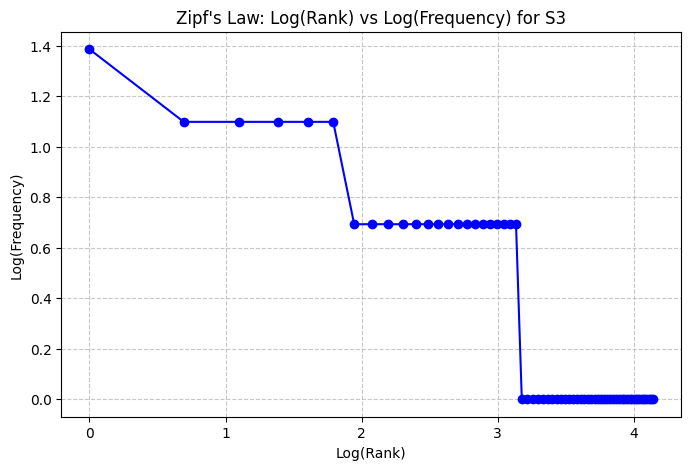


=== Top 5 Bigrams in S1 ===
('.', 'the'): 4
('.', 'please'): 4
('please', 'help'): 3
('help', '.'): 3
('.', 'can'): 3

=== Top 5 Bigrams in S3 ===
('please', 'help'): 3
('student', 'portal'): 2
('problem', 'occurs'): 2
('use', 'mobile'): 2
('mobile', 'hotspot'): 2


In [29]:
import math
from collections import Counter
import matplotlib.pyplot as plt
from nltk.stem import PorterStemmer
from nltk.util import bigrams
import pandas as pd

# --- 1. Gather Token Sets ---
# S1: All tokens
s1_tokens = []
for text in df['Ticket_Text']:
    s1_tokens.extend(process_ticket(text)['tokens'])

# S2: No punctuation
s2_tokens = []
for text in df['Ticket_Text']:
    processed = process_ticket(text)
    # Filter out punctuation
    s2_tokens.extend([t for t in processed['tokens'] if not is_punct(t)])

# S3: Final tokens (no punctuation, no stopwords)
s3_tokens = []
for text in df['Ticket_Text']:
    s3_tokens.extend(process_ticket(text)['final'])

# S4: S3 after Porter stemming
porter = PorterStemmer()
s4_tokens = [porter.stem(t) for t in s3_tokens]

# --- 2. Compute TTR and Statistics ---
stats = []
for label, tokens in zip(["S1 (All)", "S2 (No Punct)", "S3 (Final)", "S4 (S3 + Porter)"], [s1_tokens, s2_tokens, s3_tokens, s4_tokens]):
    total_t = len(tokens)
    unique_t = len(set(tokens))
    ttr = unique_t / total_t if total_t > 0 else 0
    stats.append({
        "Set": label,
        "Tokens": total_t,
        "Unique Tokens": unique_t,
        "TTR": round(ttr, 4)
    })

stats_df = pd.DataFrame(stats)
print("=== Corpus Statistics ===")
display(stats_df)
print()

# --- 3. Top 10 Words ---
print("=== Top 10 Words in S1 ===")
s1_counts = Counter(s1_tokens)
for word, count in s1_counts.most_common(10):
    print(f"{word}: {count}")
print()

print("=== Top 10 Words in S3 ===")
s3_counts = Counter(s3_tokens)
for word, count in s3_counts.most_common(10):
    print(f"{word}: {count}")
print()

# --- 4. Plot log(rank) vs log(frequency) for S3 ---
# Sort frequencies
frequencies = sorted(s3_counts.values(), reverse=True)
ranks = list(range(1, len(frequencies) + 1))

log_ranks = [math.log(r) for r in ranks]
log_freqs = [math.log(f) for f in frequencies]

plt.figure(figsize=(8, 5))
plt.plot(log_ranks, log_freqs, marker='o', linestyle='-', color='b')
plt.title("Zipf's Law: Log(Rank) vs Log(Frequency) for S3")
plt.xlabel("Log(Rank)")
plt.ylabel("Log(Frequency)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- 5. Top 5 Bigrams ---
print("\n=== Top 5 Bigrams in S1 ===")
s1_bigrams = list(bigrams(s1_tokens))
s1_bigram_counts = Counter(s1_bigrams)
for bigram, count in s1_bigram_counts.most_common(5):
    print(f"{bigram}: {count}")
print()

print("=== Top 5 Bigrams in S3 ===")
s3_bigrams = list(bigrams(s3_tokens))
s3_bigram_counts = Counter(s3_bigrams)
for bigram, count in s3_bigram_counts.most_common(5):
    print(f"{bigram}: {count}")

**Observe:** Why does TTR change from S1 to S4 in your data?

*Your answer:*
- **S1 to S2**: The TTR increases because we remove punctuation marks. Punctuation tokens are highly repetitive (for example, the period '.' appears 25 times), so removing them drastically decreases the total token count ($N$) while barely reducing the unique vocabulary size ($V$).
- **S2 to S3**: The TTR increases further because we filter out stopwords. Stopwords (like 'the', 'is', 'i', 'can', 'it') are highly frequent functional words. Removing them significantly reduces the denominator ($N$) while keeping the key vocabulary terms, raising the ratio of unique terms to total terms.
- **S3 to S4**: The TTR decreases slightly. Stemming collapses morphological variants of words to a single root form (for example, mapping 'works' and 'working' to 'work'). This decreases the number of unique tokens ($V$) while keeping the total number of tokens ($N$) exactly the same, thereby decreasing the TTR.